In [1]:
# 1. Setup — only libraries that already ship with Colab
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 110
pd.set_option('display.max_colwidth', 40)
print("Environment ready ✅")

Environment ready ✅


## 2. The Backlog

Ten candidate initiatives, each already scored 1–10 by the product trio on four inputs:

| Field | Meaning |
|---|---|
| `business_value` | Value to the user / business if shipped now |
| `time_criticality` | Value decays the longer we wait (deadlines, seasonality, competitor moves) |
| `risk_reduction` | How much shipping this reduces risk or unlocks other opportunities (RR/OE) |
| `job_size` | Relative effort — story points / weeks of engineering time |

Feel free to edit the table below with your own backlog.


In [2]:
# 2. Sample backlog — edit freely
backlog = pd.DataFrame([
    {"initiative": "One-click checkout",          "business_value": 8, "time_criticality": 7, "risk_reduction": 4, "job_size": 3,
     "cost_usd": 40_000,  "benefit_usd": 260_000},
    {"initiative": "Mobile push notifications",    "business_value": 6, "time_criticality": 5, "risk_reduction": 3, "job_size": 2,
     "cost_usd": 25_000,  "benefit_usd": 90_000},
    {"initiative": "Multi-currency pricing",       "business_value": 7, "time_criticality": 8, "risk_reduction": 6, "job_size": 8,
     "cost_usd": 120_000, "benefit_usd": 300_000},
    {"initiative": "Referral program",             "business_value": 9, "time_criticality": 4, "risk_reduction": 5, "job_size": 5,
     "cost_usd": 60_000,  "benefit_usd": 340_000},
    {"initiative": "Legacy API migration",         "business_value": 3, "time_criticality": 9, "risk_reduction": 8, "job_size": 13,
     "cost_usd": 200_000, "benefit_usd": 150_000},
    {"initiative": "In-app support chat",          "business_value": 6, "time_criticality": 3, "risk_reduction": 2, "job_size": 5,
     "cost_usd": 55_000,  "benefit_usd": 110_000},
    {"initiative": "Personalized recommendations", "business_value": 8, "time_criticality": 5, "risk_reduction": 5, "job_size": 8,
     "cost_usd": 100_000, "benefit_usd": 280_000},
    {"initiative": "GDPR consent overhaul",        "business_value": 2, "time_criticality": 10,"risk_reduction": 9, "job_size": 5,
     "cost_usd": 70_000,  "benefit_usd": 80_000},
    {"initiative": "Dark mode",                    "business_value": 4, "time_criticality": 2, "risk_reduction": 1, "job_size": 2,
     "cost_usd": 15_000,  "benefit_usd": 40_000},
    {"initiative": "A/B testing platform",         "business_value": 5, "time_criticality": 4, "risk_reduction": 7, "job_size": 8,
     "cost_usd": 90_000,  "benefit_usd": 130_000},
])
backlog

,initiative,business_value,time_criticality,risk_reduction,job_size,cost_usd,benefit_usd
0,One-click checkout,8,7,4,3,40000,260000
1,Mobile push notifications,6,5,3,2,25000,90000
2,Multi-currency pricing,7,8,6,8,120000,300000
3,Referral program,9,4,5,5,60000,340000
4,Legacy API migration,3,9,8,13,200000,150000
5,In-app support chat,6,3,2,5,55000,110000
6,Personalized recommendations,8,5,5,8,100000,280000
7,GDPR consent overhaul,2,10,9,5,70000,80000
8,Dark mode,4,2,1,2,15000,40000
9,A/B testing platform,5,4,7,8,90000,130000


## 3. WSJF Score

$$
WSJF = \frac{Business\ Value + Time\ Criticality + Risk\ Reduction / Opportunity\ Enablement}{Job\ Size}
$$

Higher WSJF = do it sooner (high value / urgency / risk-reduction, delivered cheaply).


In [3]:
# 3. Compute WSJF
backlog["cost_of_delay"] = (
    backlog["business_value"] + backlog["time_criticality"] + backlog["risk_reduction"]
)
backlog["wsjf"] = (backlog["cost_of_delay"] / backlog["job_size"]).round(2)

# 4. Compute a simple ROI (%) for comparison
backlog["roi_pct"] = (
    (backlog["benefit_usd"] - backlog["cost_usd"]) / backlog["cost_usd"] * 100
).round(0)

ranked_wsjf = backlog.sort_values("wsjf", ascending=False).reset_index(drop=True)
ranked_wsjf.index += 1
ranked_wsjf[["initiative", "cost_of_delay", "job_size", "wsjf", "roi_pct"]]

,initiative,cost_of_delay,job_size,wsjf,roi_pct
1,Mobile push notifications,14,2,7.00,260.0
2,One-click checkout,19,3,6.33,550.0
3,GDPR consent overhaul,21,5,4.20,14.0
4,Referral program,18,5,3.60,467.0
5,Dark mode,7,2,3.50,167.0
6,Multi-currency pricing,21,8,2.62,150.0
7,Personalized recommendations,18,8,2.25,180.0
8,In-app support chat,11,5,2.20,100.0
9,A/B testing platform,16,8,2.00,44.0
10,Legacy API migration,20,13,1.54,-25.0


## 4. Visualize: WSJF ranking

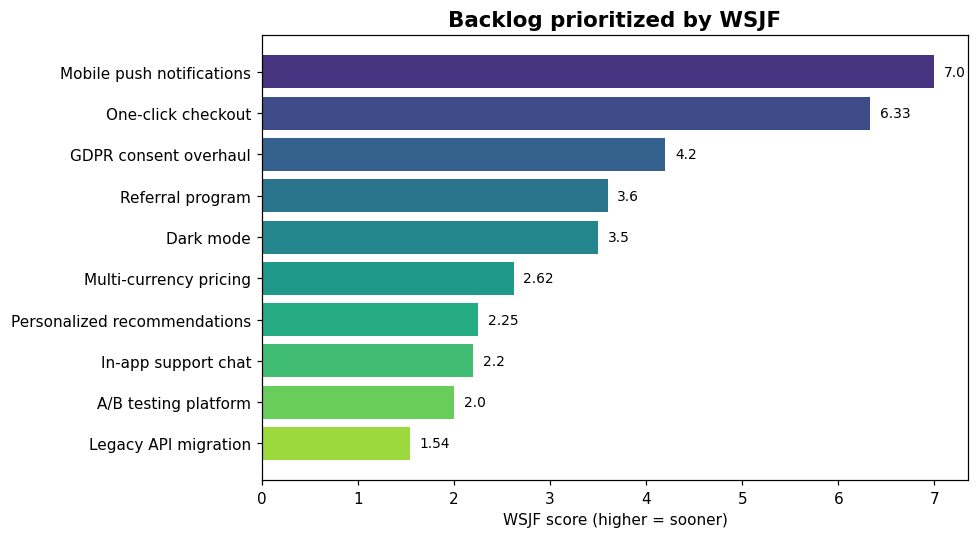

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(ranked_wsjf)))
bars = ax.barh(ranked_wsjf["initiative"], ranked_wsjf["wsjf"], color=colors)
ax.invert_yaxis()
ax.set_xlabel("WSJF score (higher = sooner)")
ax.set_title("Backlog prioritized by WSJF", fontsize=14, fontweight="bold")
for bar, val in zip(bars, ranked_wsjf["wsjf"]):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2, f"{val}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

## 5. WSJF rank vs. ROI rank — do they agree?

A quick sanity check every team should run: ranking by **WSJF** (value ÷ effort, time-boxed) and
ranking by pure **ROI %** can disagree — WSJF often promotes urgent/risk-reducing work
(e.g. compliance) that has weak standalone ROI but high cost-of-delay.


In [5]:
compare = backlog.copy()
compare["wsjf_rank"] = compare["wsjf"].rank(ascending=False).astype(int)
compare["roi_rank"] = compare["roi_pct"].rank(ascending=False).astype(int)
compare["rank_delta"] = compare["roi_rank"] - compare["wsjf_rank"]
compare = compare.sort_values("wsjf_rank")

display(compare[["initiative", "wsjf_rank", "roi_rank", "rank_delta"]]
        .set_index("initiative"))

biggest_mover = compare.loc[compare["rank_delta"].abs().idxmax()]
print(f"\nBiggest disagreement: '{biggest_mover['initiative']}' "
      f"(WSJF rank {int(biggest_mover['wsjf_rank'])} vs ROI rank {int(biggest_mover['roi_rank'])}) — "
      f"WSJF's time-criticality / risk-reduction terms are pulling this one forward "
      f"even though its dollar ROI alone wouldn't justify the priority.")

,wsjf_rank,roi_rank,rank_delta
initiative,,,
Mobile push notifications,1,3,2
One-click checkout,2,1,-1
GDPR consent overhaul,3,9,6
Referral program,4,2,-2
Dark mode,5,5,0
Multi-currency pricing,6,6,0
Personalized recommendations,7,4,-3
In-app support chat,8,7,-1
A/B testing platform,9,8,-1



Biggest disagreement: 'GDPR consent overhaul' (WSJF rank 3 vs ROI rank 9) — WSJF's time-criticality / risk-reduction terms are pulling this one forward even though its dollar ROI alone wouldn't justify the priority.


## 6. Try it yourself — interactive re-scoring

Move the sliders to re-score **one** initiative live and watch it jump up or down the
prioritized list. This is exactly the conversation a prioritization workshop should produce:
*"if we believe time-criticality is really a 9, not a 5, here's what changes."*


In [6]:
import ipywidgets as widgets
from IPython.display import display, clear_output

item_dropdown = widgets.Dropdown(
    options=list(backlog["initiative"]), description="Initiative:",
    style={"description_width": "initial"}, layout=widgets.Layout(width="350px"))
bv_slider = widgets.IntSlider(value=5, min=1, max=10, description="Business value")
tc_slider = widgets.IntSlider(value=5, min=1, max=10, description="Time criticality")
rr_slider = widgets.IntSlider(value=5, min=1, max=10, description="Risk reduction")
js_slider = widgets.IntSlider(value=5, min=1, max=13, description="Job size")
out = widgets.Output()

def sync_sliders(change=None):
    row = backlog[backlog["initiative"] == item_dropdown.value].iloc[0]
    bv_slider.value, tc_slider.value = int(row.business_value), int(row.time_criticality)
    rr_slider.value, js_slider.value = int(row.risk_reduction), int(row.job_size)

def redraw(change=None):
    temp = backlog.copy()
    mask = temp["initiative"] == item_dropdown.value
    temp.loc[mask, "business_value"] = bv_slider.value
    temp.loc[mask, "time_criticality"] = tc_slider.value
    temp.loc[mask, "risk_reduction"] = rr_slider.value
    temp.loc[mask, "job_size"] = js_slider.value
    temp["wsjf"] = ((temp.business_value + temp.time_criticality + temp.risk_reduction)
                     / temp.job_size).round(2)
    temp = temp.sort_values("wsjf", ascending=False).reset_index(drop=True)
    temp.index += 1
    with out:
        clear_output(wait=True)
        display(temp[["initiative", "wsjf"]].style.apply(
            lambda s: ['background-color: #cadcfc' if v == item_dropdown.value else ''
                       for v in temp["initiative"]], axis=0, subset=["initiative"]))

item_dropdown.observe(lambda c: (sync_sliders(), redraw()), names="value")
for s in (bv_slider, tc_slider, rr_slider, js_slider):
    s.observe(redraw, names="value")

sync_sliders(); redraw()
display(widgets.VBox([item_dropdown, bv_slider, tc_slider, rr_slider, js_slider, out]))

## 7. Takeaways

- **WSJF favors small, urgent, risk-reducing work** over big-bang high-ROI bets — that's by design: it optimizes for *economic throughput*, not just value.
- Re-run this notebook with your **real backlog** by editing the DataFrame in Section 2.
- Pair this with the OKR/roadmap notebook to trace: *Objective → Key Result → WSJF-ranked initiative → Sprint*.

**Lab exercise:** Replace the 10 sample rows with your team's actual backlog and screenshot the resulting ranked chart for your outcome-based intent document.


,initiative,reach,impact,confidence,effort,rice_score
1,One-click checkout,765,8,0.70,3,1428.00
2,Referral program,1000,9,0.75,5,1350.00
3,Personalized recommendations,824,8,0.75,8,618.00
4,Multi-currency pricing,882,7,0.80,8,617.40
5,Mobile push notifications,265,6,0.65,2,516.75
6,In-app support chat,324,6,0.60,5,233.28
7,A/B testing platform,382,5,0.85,8,202.94
8,Dark mode,118,4,0.55,2,129.80
9,Legacy API migration,441,3,0.90,13,91.59
10,GDPR consent overhaul,235,2,0.95,5,89.30


,rice_rank,wsjf_rank,roi_rank
initiative,,,
One-click checkout,1,2,1
Referral program,2,4,2
Personalized recommendations,3,7,4
Multi-currency pricing,4,6,6
Mobile push notifications,5,1,3
In-app support chat,6,8,7
A/B testing platform,7,9,8
Dark mode,8,5,5
Legacy API migration,9,10,10


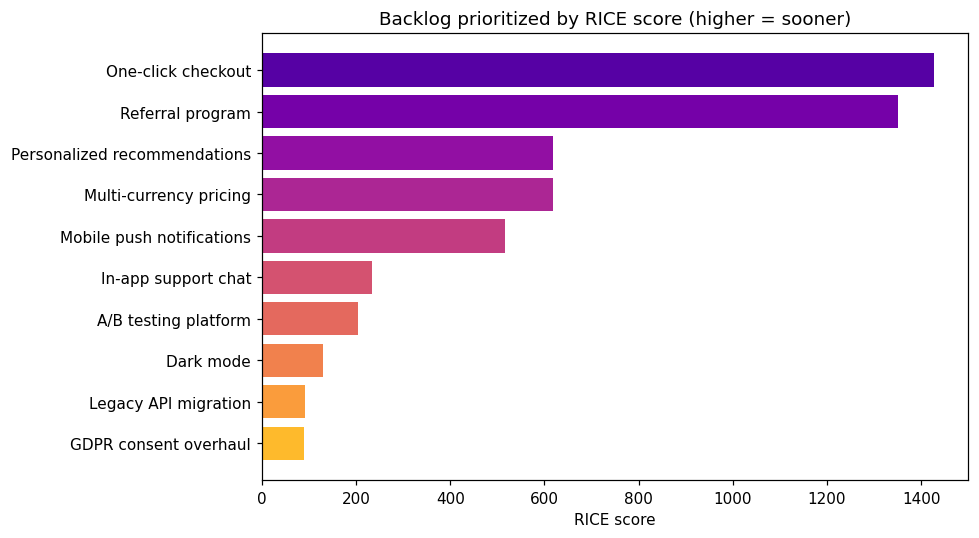

Notes: Defaults computed automatically when `reach/impact/confidence/effort` are missing.
Edit the `backlog` DataFrame to provide custom R/I/C/E values and re-run this cell.


In [7]:
# 8. RICE Prioritization (Reach, Impact, Confidence, Effort)
import numpy as np

# Work on a copy to avoid accidentally mutating the original backlog until you're ready
rice = backlog.copy()

# Provide sensible defaults when the columns are missing
if 'reach' not in rice.columns:
    # Derive reach from benefit_usd scaled to 1..1000 when available, otherwise use a uniform placeholder
    if 'benefit_usd' in rice.columns and rice['benefit_usd'].max() > 0:
        rice['reach'] = (rice['benefit_usd'] / rice['benefit_usd'].max() * 1000).round().astype(int)
    else:
        rice['reach'] = 1000

if 'impact' not in rice.columns:
    # Use `business_value` (1-10) as a proxy for impact
    rice['impact'] = rice['business_value']

if 'confidence' not in rice.columns:
    # Derive a confidence estimate from risk_reduction (0.5 + 0.05*RR), clamp to [0.3, 1.0]
    rice['confidence'] = (0.5 + 0.05 * rice['risk_reduction']).clip(0.3, 1.0).round(2)

if 'effort' not in rice.columns:
    # Use job_size as effort (same units assumed)
    rice['effort'] = rice['job_size']

# Compute the RICE score: (Reach * Impact * Confidence) / Effort
rice['rice_score'] = ((rice['reach'] * rice['impact'] * rice['confidence']) / rice['effort']).round(2)

# Present sorted results
rice_sorted = rice.sort_values('rice_score', ascending=False).reset_index(drop=True)
rice_sorted.index += 1
display(rice_sorted[['initiative','reach','impact','confidence','effort','rice_score']])

# Compare RICE ranks against WSJF and ROI ranks
compare_rice = rice.copy()
compare_rice['rice_rank'] = compare_rice['rice_score'].rank(ascending=False).astype(int)
# ensure wsjf and roi_pct exist (they should from earlier cells)
if 'wsjf' not in compare_rice.columns:
    compare_rice['wsjf'] = ( (compare_rice['business_value'] + compare_rice['time_criticality'] + compare_rice['risk_reduction']) / compare_rice['job_size'] ).round(2)
if 'roi_pct' not in compare_rice.columns and 'benefit_usd' in compare_rice.columns and 'cost_usd' in compare_rice.columns:
    compare_rice['roi_pct'] = ((compare_rice['benefit_usd'] - compare_rice['cost_usd']) / compare_rice['cost_usd'] * 100).round(0)
compare_rice['wsjf_rank'] = compare_rice['wsjf'].rank(ascending=False).astype(int)
if 'roi_pct' in compare_rice.columns:
    compare_rice['roi_rank'] = compare_rice['roi_pct'].rank(ascending=False).astype(int)
else:
    compare_rice['roi_rank'] = np.nan

display(compare_rice[['initiative','rice_rank','wsjf_rank','roi_rank']].sort_values('rice_rank').set_index('initiative'))

# Plot RICE scores
import matplotlib.pyplot as plt
plt.figure(figsize=(9,5))
colors = plt.cm.plasma(np.linspace(0.15,0.85,len(rice_sorted)))
plt.barh(rice_sorted['initiative'], rice_sorted['rice_score'], color=colors)
plt.gca().invert_yaxis()
plt.title('Backlog prioritized by RICE score (higher = sooner)')
plt.xlabel('RICE score')
plt.tight_layout()
plt.show()

print('Notes: Defaults computed automatically when `reach/impact/confidence/effort` are missing.')
print('Edit the `backlog` DataFrame to provide custom R/I/C/E values and re-run this cell.')